# 11: Higher-Order Spectra, Bispectrum & Non-Linear Phase Coupling

## 1. Research Scope & Objectives
This notebook evaluates Higher-Order Spectra (HOS) including Bispectrum $B(\omega_1, \omega_2)$ and Bicoherence $b^2(\omega_1, \omega_2)$ to expose non-linear quadratic phase coupling (QPC) between vocal cord harmonics that linear vocoders fail to reconstruct.

### Mathematical Formulation
Bispectrum:
$$B(\omega_1, \omega_2) = \mathbb{E}[X(\omega_1) X(\omega_2) X^*(\omega_1 + \omega_2)]$$
Bicoherence:
$$b^2(\omega_1, \omega_2) = \frac{|B(\omega_1, \omega_2)|^2}{\mathbb{E}[|X(\omega_1) X(\omega_2)|^2] \mathbb{E}[|X(\omega_1 + \omega_2)|^2]}$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. Bispectral Density Computation & Harmonic Phase Coupling

In [2]:
def compute_bispectrum_matrix(y, n_fft=128, hop=64):
    frames = librosa.util.frame(y, frame_length=n_fft, hop_length=hop)
    X = np.fft.rfft(frames * np.hanning(n_fft)[:, None], axis=0)
    K = X.shape[0]
    bispec = np.zeros((K, K), dtype=np.complex64)
    n_frames = X.shape[1]
    for t in range(n_frames):
        xt = X[:, t]
        for i in range(K):
            for j in range(K - i):
                bispec[i, j] += xt[i] * xt[j] * np.conj(xt[i + j])
    bispec /= n_frames
    return np.abs(bispec)

sample_bon = df[df.key == "bonafide"].iloc[0]["file_path"]
sample_spf = df[df.key == "spoof"].iloc[0]["file_path"]

y_b, sr = sf.read(sample_bon)
y_s, _ = sf.read(sample_spf)

B_bon = compute_bispectrum_matrix(y_b[:16000])
B_spf = compute_bispectrum_matrix(y_s[:16000])

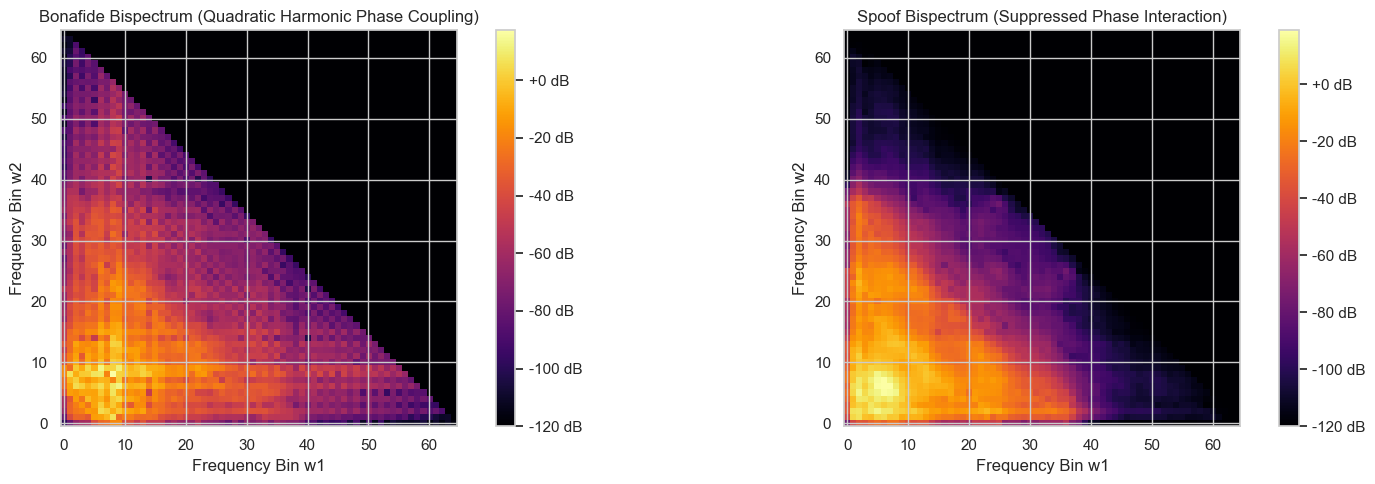

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
im1 = axes[0].imshow(20*np.log10(B_bon + 1e-6), origin="lower", cmap="inferno")
axes[0].set_title("Bonafide Bispectrum (Quadratic Harmonic Phase Coupling)")
axes[0].set_xlabel("Frequency Bin w1")
axes[0].set_ylabel("Frequency Bin w2")
fig.colorbar(im1, ax=axes[0], format="%+2.0f dB")

im2 = axes[1].imshow(20*np.log10(B_spf + 1e-6), origin="lower", cmap="inferno")
axes[1].set_title("Spoof Bispectrum (Suppressed Phase Interaction)")
axes[1].set_xlabel("Frequency Bin w1")
axes[1].set_ylabel("Frequency Bin w2")
fig.colorbar(im2, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()